In [3]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols
import plotly.express as px
import plotly.io as pio

pio.templates.default = "plotly_dark"
np.random.seed(42)
n_samples = 100

shifts = np.random.choice(['Morning', 'Night'], size=n_samples)
training = np.random.choice(['Certified', 'Non-Certified'], size=n_samples)
performance = []

for s, t in zip(shifts, training):
    base = 75
    if s == 'Morning': base += 5
    if t == 'Certified': base += 10
    noise = np.random.normal(0, 4)
    final_score = max(50, min(100, base + noise))
    performance.append(round(final_score, 2))

df_bank = pd.DataFrame({
    'Shift': list(shifts),
    'Training': list(training),
    'Performance_Score': list(performance)
})
print(f"Data ingestion complete. Total records: {len(df_bank)}")

Data ingestion complete. Total records: 100


In [4]:
formula = 'Performance_Score ~ C(Shift) + C(Training) + C(Shift):C(Training)'
model = ols(formula, data=df_bank).fit()
anova_results = sm.stats.anova_lm(model, typ=2)

print(anova_results)

                           sum_sq    df           F        PR(>F)
C(Shift)               630.749536   1.0   46.814119  7.298116e-10
C(Training)           1981.229195   1.0  147.046482  4.486154e-21
C(Shift):C(Training)     0.153346   1.0    0.011381  9.152628e-01
Residual              1293.454970  96.0         NaN           NaN


In [5]:
p_shift = anova_results.loc['C(Shift)', 'PR(>F)']
p_training = anova_results.loc['C(Training)', 'PR(>F)']
p_interaction = anova_results.loc['C(Shift):C(Training)', 'PR(>F)']
alpha = 0.05

if p_shift < alpha: print(f"Shift has a SIGNIFICANT impact (p={p_shift:.5f}).")
else: print(f"Shift has NO significant impact (p={p_shift:.5f}).")

if p_training < alpha: print(f"Training has a MASSIVE impact (p={p_training:.5f}).")
else: print(f"Training has NO noticeable impact (p={p_training:.5f}).")

if p_interaction < alpha: print(f"CRITICAL! Interaction effect is SIGNIFICANT (p={p_interaction:.5f}).")
else: print(f"Interaction effect is NOT significant (p={p_interaction:.5f}).")

Shift has a SIGNIFICANT impact (p=0.00000).
Training has a MASSIVE impact (p=0.00000).
Interaction effect is NOT significant (p=0.91526).


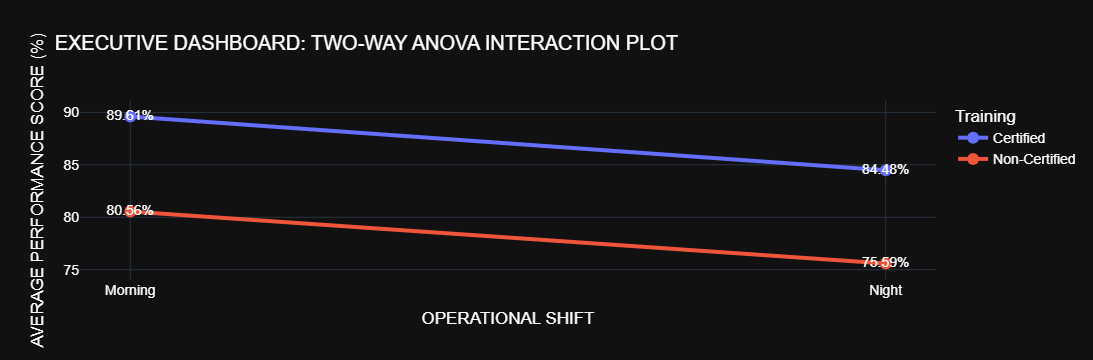

In [6]:
df_plot = df_bank.groupby(['Shift', 'Training'])['Performance_Score'].mean().reset_index()
df_plot['Performance_Score'] = df_plot['Performance_Score'].round(2)

fig = px.line(df_plot, x='Shift', y='Performance_Score', color='Training', 
              markers=True, text=df_plot['Performance_Score'].apply(lambda x: f'{x}%'),
              title="EXECUTIVE DASHBOARD: TWO-WAY ANOVA INTERACTION PLOT")

fig.update_traces(marker=dict(size=12), line=dict(width=4))
fig.update_layout(xaxis_title="OPERATIONAL SHIFT", yaxis_title="AVERAGE PERFORMANCE SCORE (%)",
                  font=dict(family="Arial", size=14, color="White"), hovermode="x unified")

fig.write_html("MNC_ANOVA_Interactive_Dashboard.html")
fig.show()